In [47]:
import pandas as pd

df = pd.read_csv('../players.csv')
df.head()


,Squad,Comp,Player,Nation,Pos,Age,Born,MP,Minutes_Played,Mn_per_MP,...,Launch_percent_Passes_GK,AvgLen_Passes_GK,Att_Goal_Kicks_GK,AvgLen_GoalKick_GK,CrossesFaced_GK,CrossedStopped_GK,CrossedStopped_Perc_GK,OPA_Sweeper_GK,OPA_per_90_Sweeper_GK,AvgDist_Sweeper_GK
0,Ajaccio,Ligue 1,Mickaël Alphonse,GLP,DF,33,1989,26,1361.0,52.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ajaccio,Ligue 1,Cédric Avinel,GLP,DF,35,1986,24,1794.0,75.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ajaccio,Ligue 1,Mickaël Barreto,FRA,MF,31,1991,20,1325.0,66.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Ajaccio,Ligue 1,Cyrille Bayala,BFA,MF,26,1996,33,2009.0,61.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Ajaccio,Ligue 1,Youcef Belaïli,ALG,"MF,FW",30,1992,17,1150.0,68.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
for col in df.columns:
    print(col)

Squad
Comp
Player
Nation
Pos
Age
Born
MP
Minutes_Played
Mn_per_MP
Mins_Per_90
Starts
PPM_Team.Success
onG_Team.Success
onGA_Team.Success
plus_per__minus__Team.Success
Goals
Assists
GoalsAssistsCombined
NonPKG
PK
PKatt
CrdY
CrdR
xG
xAG
npxG+xAG
PrgC
PrgP
Gls_Per90
Ast_Per90
G+A_Per90
G_minus_PK_Per
G+A_minus_PK_Per
xG_Per
xAG_Per
xG+xAG_Per
Shots
Shots_on_Target
SoT_percent
G_per_Sh
G_per_SoT
Avg_Shot_Dist
FK_Standard
G_minus_xG_Expected
np:G_minus_xG_Expected
Passes_Completed
Passes_Attempted
Passes_Cmp_percent
PrgDist_Total
Passes_Cmp_Short
Passes_Att_Short
Passes_Cmp_percent_Short
Passes_Cmp_Medium
Passes_Att_Medium
Passes_Cmp_percent_Medium
Passes_Cmp_Long
Passes_Att_Long
Passes_Cmp_percent_Long
xA_Expected
A_minus_xAG_Expected
Key_Passes
Final_Third
PPA
CrsPA
TB_Pass
Crs_Pass
Offside_Passes
Blocked_Passes
Shot_Creating_Actions
SCA_90
TakeOnTo_Shot
FoulTo_Shot
DefAction_Shot
GoalCreatingAction
GCA90
TakeOn_Goal
Fld_Goal
DefAction_Goal
Tackles
Tackles_Won
Def_3rd_Tackles
Mid_3rd_Tack

In [49]:
# create new variables
df['efficiency'] = df['Goals'] / df['xG']
df['overperformance'] = df['Goals'] - df['xG']

df[['Player', 'Goals', 'xG', 'efficiency', 'overperformance']].head()

,Player,Goals,xG,efficiency,overperformance
0,Mickaël Alphonse,0.0,0.5,0.000000,-0.5
1,Cédric Avinel,1.0,1.0,1.000000,0.0
2,Mickaël Barreto,1.0,0.9,1.111111,0.1
3,Cyrille Bayala,1.0,2.0,0.500000,-1.0
4,Youcef Belaïli,6.0,6.2,0.967742,-0.2


In [50]:
# most clinical players - possible outliers
df_sorted = df.sort_values(by='efficiency', ascending=False)

type(df_sorted)

pandas.core.frame.DataFrame

In [51]:
 df_sorted[['Player', 'Goals', 'xG', 'efficiency']].head(10)

,Player,Goals,xG,efficiency
1051,Luca Koleosho,1.0,0.0,inf
3055,Adam Masina,2.0,0.1,20.0
3080,Paul Jaeckel,1.0,0.1,10.0
2272,Mattia Viti,1.0,0.1,10.0
1610,Nampalys Mendy,1.0,0.1,10.0
3195,Pascu,1.0,0.1,10.0
1568,Junior Firpo,1.0,0.1,10.0
122,Jakub Kiwior,1.0,0.1,10.0
2085,Sacha Delaye,1.0,0.1,10.0
223,Nadir Zortea,1.0,0.1,10.0


In [52]:
# most clinical players - without outliers
df_filtered = df[df['xG'] > 5]

df_filtered.sort_values(by='efficiency', ascending=False)[
    ['Player', 'Goals', 'xG', 'efficiency']
].head(10)

,Player,Goals,xG,efficiency
1737,Roberto Firmino,11.0,5.5,2.000000
1936,Phil Foden,11.0,5.9,1.864407
2604,Boulaye Dia,16.0,8.8,1.818182
710,Gabriel Veiga,11.0,6.1,1.803279
897,Julian Brandt,9.0,5.2,1.730769
3073,Sheraldo Becker,11.0,6.5,1.692308
653,Pascal Groß,9.0,5.4,1.666667
1838,Jonas Hofmann,12.0,7.2,1.666667
1785,Terem Moffi,12.0,7.3,1.643836
420,Eric Maxim Choupo-Moting,10.0,6.1,1.639344


### Top Overperforming Players

The analysis identifies players who significantly exceed their expected goals (xG), indicating high offensive efficiency.

Players such as Roberto Firmino, Phil Foden, and Boulaye Dia demonstrate strong finishing ability, scoring substantially more goals than expected based on chance quality.

This suggests that these players are either highly effective in front of goal or benefiting from favorable conditions or short-term performance trends.

### Interpretation

While overperformance may indicate strong finishing skill, it is important to consider that such results may not always be sustainable over time and could be influenced by variance.
 

### xG vs Goals Analysis

The scatter plot comparing expected goals (xG) and actual goals allows us to evaluate player performance relative to chance quality.

Players above the diagonal line outperform their expected goals, indicating higher-than-average finishing efficiency. Conversely, players below the line underperform relative to the quality of their chances.

### Interpretation

While some players show strong overperformance, it is important to consider variance, especially for players with lower xG values. Larger deviations combined with higher xG values are more likely to reflect true finishing ability rather than randomness.

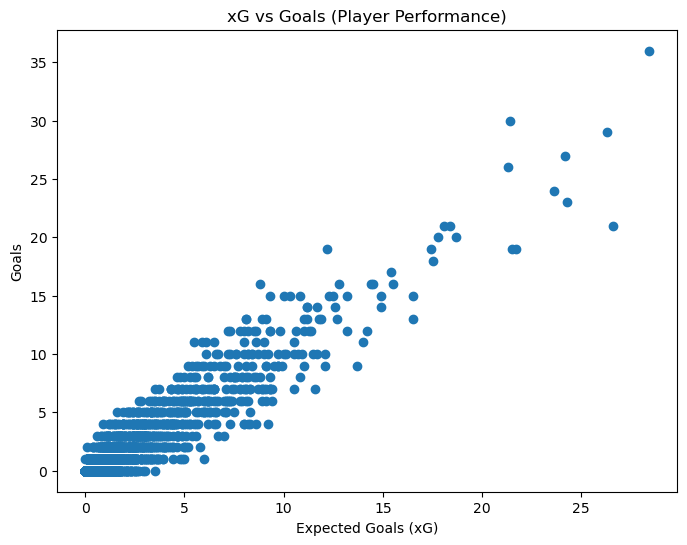

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df['xG'], df['Goals'])

plt.xlabel('Expected Goals (xG)')
plt.ylabel('Goals')
plt.title('xG vs Goals (Player Performance)')

plt.savefig('../images/xg_vs_goals.png', bbox_inches='tight')

plt.show()

### xG vs Goals Relationship

The scatter plat shows a strong positive relationship between expected goals (xG) and actual goals, indicating that chance quality is a key driver of scoring output.

Most players are distributed close to the diaginal trend, suggesting that xG is a reliable predictor of performance.

However, some players significantly outperform their expected goals, appering above the trend line. These players may demonstrate strong finishing ability, although some of this overperformance may also be influenced by variance, especially at lower xG levels.

Conversly, players below the trend line may be underperforming relative to the quality of their chances.
 

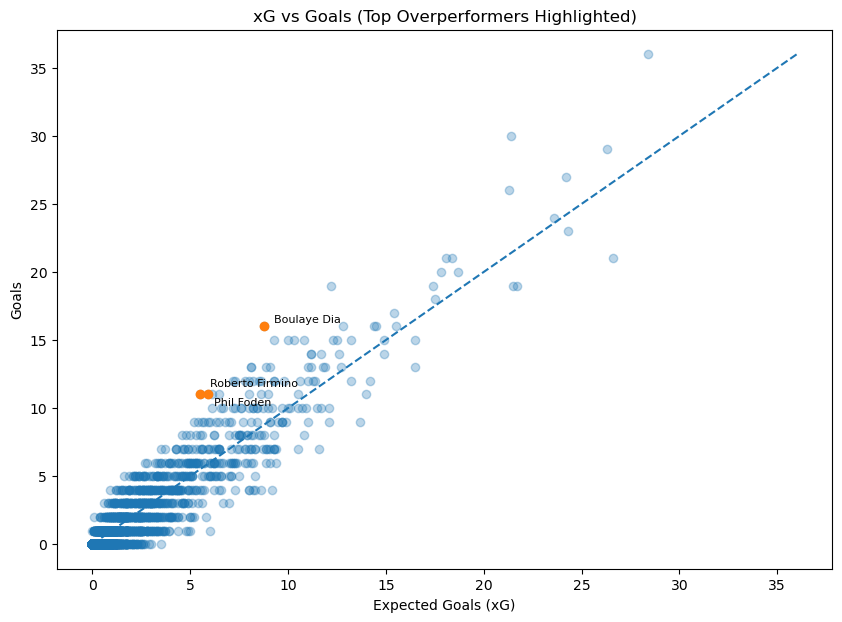

In [54]:
df_filtered = df[df['xG'] > 5]
top3 = df_filtered.sort_values(by='efficiency', ascending=False).head(3)

plt.figure(figsize=(10,7))

plt.scatter(df['xG'], df['Goals'], alpha=0.3)

plt.scatter(top3['xG'], top3['Goals'])

max_val = max(df['xG'].max(), df['Goals'].max())
plt.plot([0, max_val], [0, max_val], linestyle='--')

offsets = [
    (0.5, 0.6),
    (0.3, -0.8),
    (0.5, 0.3),
    (-1.5, 0.4),
    (0.4, -0.4)
]

for ((_, row), (dx, dy)) in zip(top3.iterrows(), offsets):
    plt.text(row['xG'] + dx, row['Goals'] + dy, row['Player'], fontsize=8)

plt.xlabel('Expected Goals (xG)')
plt.ylabel('Goals')
plt.title('xG vs Goals (Top Overperformers Highlighted)')
  
plt.savefig('../images/xg_vs_goals_labeled.png', bbox_inches='tight')


plt.show()

### Top Overperforming Players

The following players significantly exceed their expected goals (xG), indicating high finishing efficiency:

- **Roberto Firmino** (+5.5 vs xG)
- **Phil Foden** (+5.1 vs xG)
- **Boulaye Dia** (+7.2 vs xG)

These players demonstrate strong offensive performance, although part of this overperformance may be influenced by variance.


## Conclusion

This analysis explored offensive performance in European football using expected goals (xG) as a measure of chance quality.

The results show a strong positive relationship between xG and actual goals, confirming that xG is a reliable indicator of scoring potential. Most players perform close to expected levels, reinforcing the validity of the metric.

However, a subset of players consistently outperform their expected goals. Players such as Roberto Firmino, Phil Foden, and Boulaye Dia demonstrate high finishing efficiency, converting chances at a rate significantly above expectation.

While this overperformance may indicate strong finishing ability, it is important to consider the role of variance, especially in smaller sample sizes. Not all deviations from expected performance are sustainable over time.

Overall, this analysis highlights the value of combining statistical models like xG with contextual interpretation to better understand player performance beyond raw goal totals.